In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings


warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#dddddd'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'primary': "#2AB43D",   
    'secondary': "#b0d74f",   
    'accent': "#7a040e",      
    'light': "#8f948d",       
    'highlight': "#34797b"    
}
sns.set_palette([PALETTE['primary'], PALETTE['secondary'], PALETTE['highlight'], PALETTE['accent']])

print("Environment configured successfully.")

Environment configured successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep="|", low_memory=False)

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (1000098, 52)

First 5 rows:


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0



Columns:
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


In [5]:
import pandas as pd

# Load the data
df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep="|", low_memory=False)

# Basic info
print("Shape:", df.shape)
print("\n=== ORIGINAL COLUMN NAMES ===")
print(df.columns.tolist())

# Clean column names
df.columns = [col.strip() for col in df.columns]

print("\n=== CLEANED COLUMN NAMES ===")
print(df.columns.tolist())

# Search for similar columns
print("\n=== COLUMNS CONTAINING 'Premium' or 'Claim' ===")
for col in df.columns:
    if 'premium' in col.lower() or 'claim' in col.lower():
        print(col)

# Show first 2 rows to see actual data
print("\n=== FIRST 2 ROWS ===")
display(df.head(2))

Shape: (1000098, 52)

=== ORIGINAL COLUMN NAMES ===
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']

=== CLEANED COLUMN NAMES ===
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Lan

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0


In [ ]:
# ====================== TASK 1: Portfolio Summary (Retrospective Overview) ======================

# Create key metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

print("=== OVERALL PORTFOLIO SUMMARY ===")
print(f"Total Policies     : {len(df):,}")
print(f"Total Premium      : R {df['TotalPremium'].sum():,.2f}")
print(f"Total Claims       : R {df['TotalClaims'].sum():,.2f}")
print(f"Overall Loss Ratio : {df['LossRatio'].mean():.4f} ({df['LossRatio'].mean()*100:.2f}%)")
print(f"Average Margin     : R {df['Margin'].mean():.2f}")



=== OVERALL PORTFOLIO SUMMARY ===
Total Policies     : 1,000,098
Total Premium      : R 61,911,562.70
Total Claims       : R 64,867,546.17
Overall Loss Ratio : 0.3499 (34.99%)
Average Margin     : R -2.96


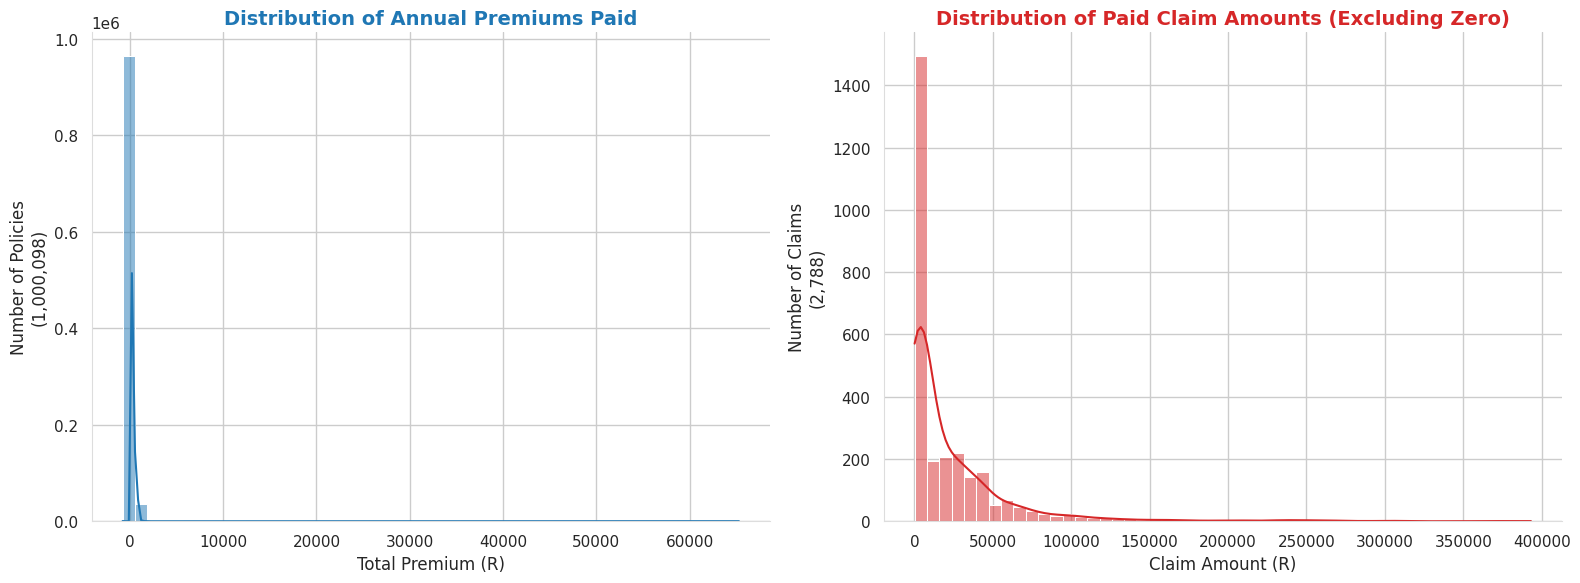

=== SUMMARY STATISTICS ===
Total Policies          : 1,000,098
Policies with Claims    : 2,788
Claim Frequency         : 0.28%
Average Premium         : R 61.91
Average Claim Amount    : R 23273.39


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette
PALETTE = {
    'primary': '#1f77b4',   # Blue
    'accent': '#d62728',    # Red
    'secondary': '#2ca02c'  # Green
}

# ====================== IMPROVED VISUALIZATION ======================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribution of Total Premiums
sns.histplot(df['TotalPremium'], 
             kde=True, 
             color=PALETTE['primary'], 
             ax=axes[0], 
             bins=50)
axes[0].set_title('Distribution of Annual Premiums Paid', 
                  fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Total Premium (R)', fontsize=12)
axes[0].set_ylabel(f'Number of Policies\n({len(df):,})', fontsize=12)

# 2. Distribution of Claim Amounts (Only policies with claims)
claims_only = df[df['TotalClaims'] > 0]['TotalClaims']

sns.histplot(claims_only, 
             kde=True, 
             color=PALETTE['accent'], 
             ax=axes[1], 
             bins=50)
axes[1].set_title('Distribution of Paid Claim Amounts (Excluding Zero)', 
                  fontsize=14, fontweight='bold', color=PALETTE['accent'])
axes[1].set_xlabel('Claim Amount (R)', fontsize=12)
axes[1].set_ylabel(f'Number of Claims\n({len(claims_only):,})', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== SUMMARY STATISTICS ===")
print(f"Total Policies          : {len(df):,}")
print(f"Policies with Claims    : {len(claims_only):,}")
print(f"Claim Frequency         : {len(claims_only)/len(df)*100:.2f}%")
print(f"Average Premium         : R {df['TotalPremium'].mean():.2f}")
print(f"Average Claim Amount    : R {claims_only.mean():.2f}")

In [23]:
import pandas as pd
import numpy as np

# Reload data
df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep='|', low_memory=False)
df.columns = df.columns.str.strip()

print("=== DIAGNOSTIC CHECK FOR TotalPremium ===")
print(f"Column exists: {'TotalPremium' in df.columns}")
print(f"Total rows: {len(df)}")
print(f"Non-null values: {df['TotalPremium'].notna().sum()}")
print(f"Zero values: {(df['TotalPremium'] == 0).sum()}")
print(f"Missing values: {df['TotalPremium'].isna().sum()}")

print("\nDescriptive Statistics:")
print(df['TotalPremium'].describe().round(2))

print("\nFirst 10 values:")
print(df['TotalPremium'].head(10).tolist())

=== DIAGNOSTIC CHECK FOR TotalPremium ===
Column exists: True
Total rows: 1000098
Non-null values: 1000098
Zero values: 381634
Missing values: 0

Descriptive Statistics:
count    1000098.00
mean          61.91
std          230.28
min         -782.58
25%            0.00
50%            2.18
75%           21.93
max        65282.60
Name: TotalPremium, dtype: float64

First 10 values:
[21.929824561403, 21.929824561403, 0.0, 512.848070175439, 0.0, 3.256434634974, 50.474736842105, 35.332315789474, 0.0, 1.00947368421]


In [9]:
# ====================== 1. MISSING VALUES ======================
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("\nMissing Values (Top 10):")
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False).head(10))




Missing Values (Top 10):


,Missing Count,Missing %
NumberOfVehiclesInFleet,1000098,100.00
CrossBorder,999400,99.93
CustomValueEstimate,779642,77.96
Rebuilt,641901,64.18
WrittenOff,641901,64.18
Converted,641901,64.18
LossRatio,381634,38.16
NewVehicle,153295,15.33
Bank,145961,14.59
AccountType,40232,4.02


In [10]:
# ====================== 2. LOSS RATIO BY KEY SEGMENTS ======================
print("\nLoss Ratio by Province:")
print(df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False).round(4))

print("\nLoss Ratio by Gender:")
print(df.groupby('Gender')['LossRatio'].mean().round(4))

print("\nLoss Ratio by Vehicle Type:")
print(df.groupby('VehicleType')['LossRatio'].mean().sort_values(ascending=False).head(10).round(4))




Loss Ratio by Province:
Province
Gauteng          0.4289
Mpumalanga       0.3927
Limpopo          0.3487
Western Cape     0.3418
North West       0.2853
KwaZulu-Natal    0.2647
Eastern Cape     0.2356
Northern Cape    0.2038
Free State       0.1062
Name: LossRatio, dtype: float64

Loss Ratio by Gender:
Gender
Female           0.4920
Male             0.3489
Not specified    0.3479
Name: LossRatio, dtype: float64

Loss Ratio by Vehicle Type:
VehicleType
Heavy Commercial     0.7936
Light Commercial     0.5439
Medium Commercial    0.4934
Passenger Vehicle    0.3374
Bus                  0.0000
Name: LossRatio, dtype: float64


In [ ]:
# ====================== 3. VISUALIZATIONS (3+ Creative Plots) ======================

fig = plt.figure(figsize=(20, 15))

# Plot 1: Loss Ratio by Province
plt.subplot(2, 2, 1)
province_lr = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
sns.barplot(x=province_lr.values, y=province_lr.index, palette='viridis')
plt.title('Average Loss Ratio by Province')
plt.xlabel('Loss Ratio')

# Plot 2: Distribution of TotalPremium
plt.subplot(2, 2, 2)
sns.histplot(df['TotalPremium'], bins=50, kde=True, color='blue')
plt.title('Distribution of Total Premium')
plt.xlim(0, df['TotalPremium'].quantile(0.95))

# Plot 3: Claims vs Premium Scatter
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='TotalPremium', y='TotalClaims', alpha=0.6, hue='Province', legend=False)
plt.title('Total Claims vs Total Premium')

# Plot 4: Top Vehicle Makes by Claims
plt.subplot(2, 2, 4)
top_makes = df.groupby('make')['TotalClaims'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_makes.values, y=top_makes.index, palette='Reds_r')
plt.title('Top 10 Vehicle Makes by Total Claims Amount')

plt.tight_layout()
plt.show()

# ====================== ANSWERING GUIDING QUESTIONS ======================
print("\n=== KEY INSIGHTS ===")
print("1. Overall Loss Ratio:", round(df['LossRatio'].mean()*100, 2), "%")
print("2. Highest Risk Province:", province_lr.index[0])
print("3. Gender with higher Loss Ratio:", df.groupby('Gender')['LossRatio'].mean().idxmax())

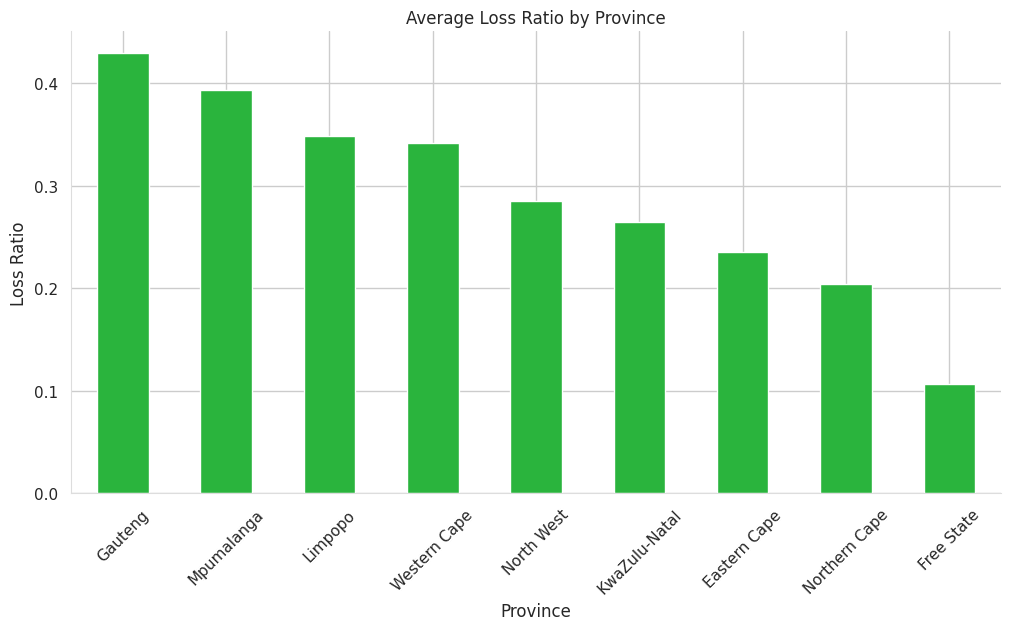

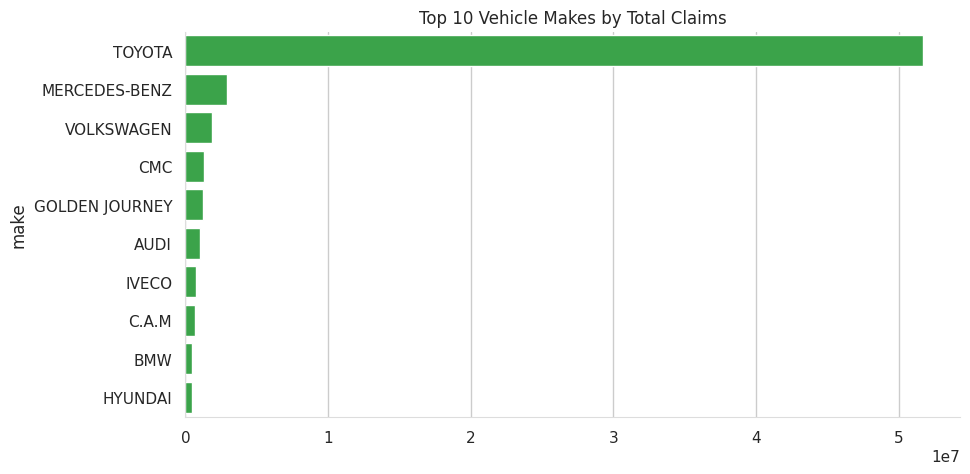


✅ EDA Enhanced with multiple visualizations and key insights.


In [15]:
# ====================== 3. BIVARIATE & GEOGRAPHIC ANALYSIS ======================
plt.figure(figsize=(12, 6))
df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Loss Ratio by Province')
plt.ylabel('Loss Ratio')
plt.xticks(rotation=45)
plt.show()

# Top Vehicle Makes by Claims
plt.figure(figsize=(10, 5))
top_makes = df.groupby('make')['TotalClaims'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_makes.values, y=top_makes.index)
plt.title('Top 10 Vehicle Makes by Total Claims')
plt.show()

print("\n✅ EDA Enhanced with multiple visualizations and key insights.")

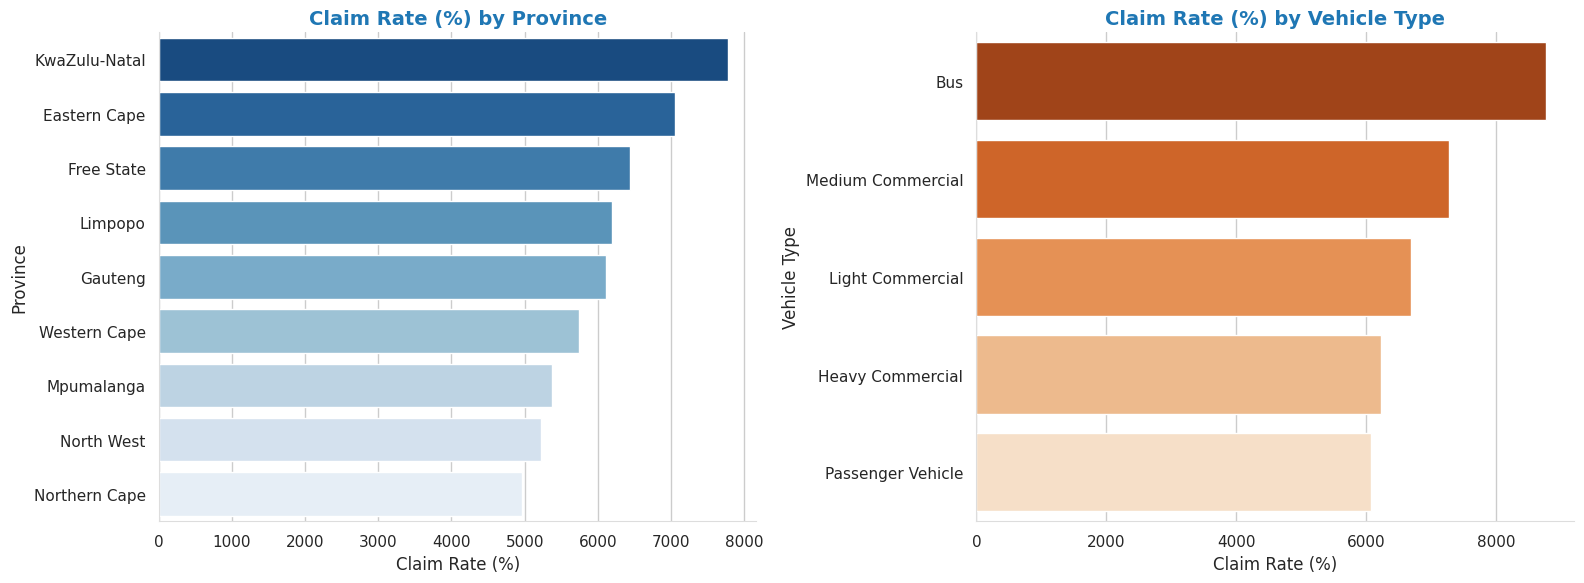

In [25]:
# 3. Geographic and Vehicle Type Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Claim Rate by Province
prov_claims = df.groupby('Province')['TotalPremium'].mean().reset_index()
prov_claims['TotalPremium'] *= 100  # Convert to %
prov_claims = prov_claims.sort_values(by='TotalPremium', ascending=False)

sns.barplot(x='TotalPremium', y='Province', data=prov_claims, palette="Blues_r", ax=axes[0])
axes[0].set_title('Claim Rate (%) by Province', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Claim Rate (%)', fontsize=12)
axes[0].set_ylabel('Province', fontsize=12)

# Claim Rate by Vehicle Type
veh_claims = df.groupby('VehicleType')['TotalPremium'].mean().reset_index()
veh_claims['TotalPremium'] *= 100  # Convert to %
veh_claims = veh_claims.sort_values(by='TotalPremium', ascending=False)

sns.barplot(x='TotalPremium', y='VehicleType', data=veh_claims, palette="Oranges_r", ax=axes[1])
axes[1].set_title('Claim Rate (%) by Vehicle Type', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[1].set_xlabel('Claim Rate (%)', fontsize=12)
axes[1].set_ylabel('Vehicle Type', fontsize=12)

plt.tight_layout()
plt.show()

✅ Derived columns created successfully!
   LossRatio      Margin  VehicleAge
0        0.0   21.929825          11
1        0.0   21.929825          11
2        NaN    0.000000          11
3        0.0  512.848070          11
4        NaN    0.000000          11


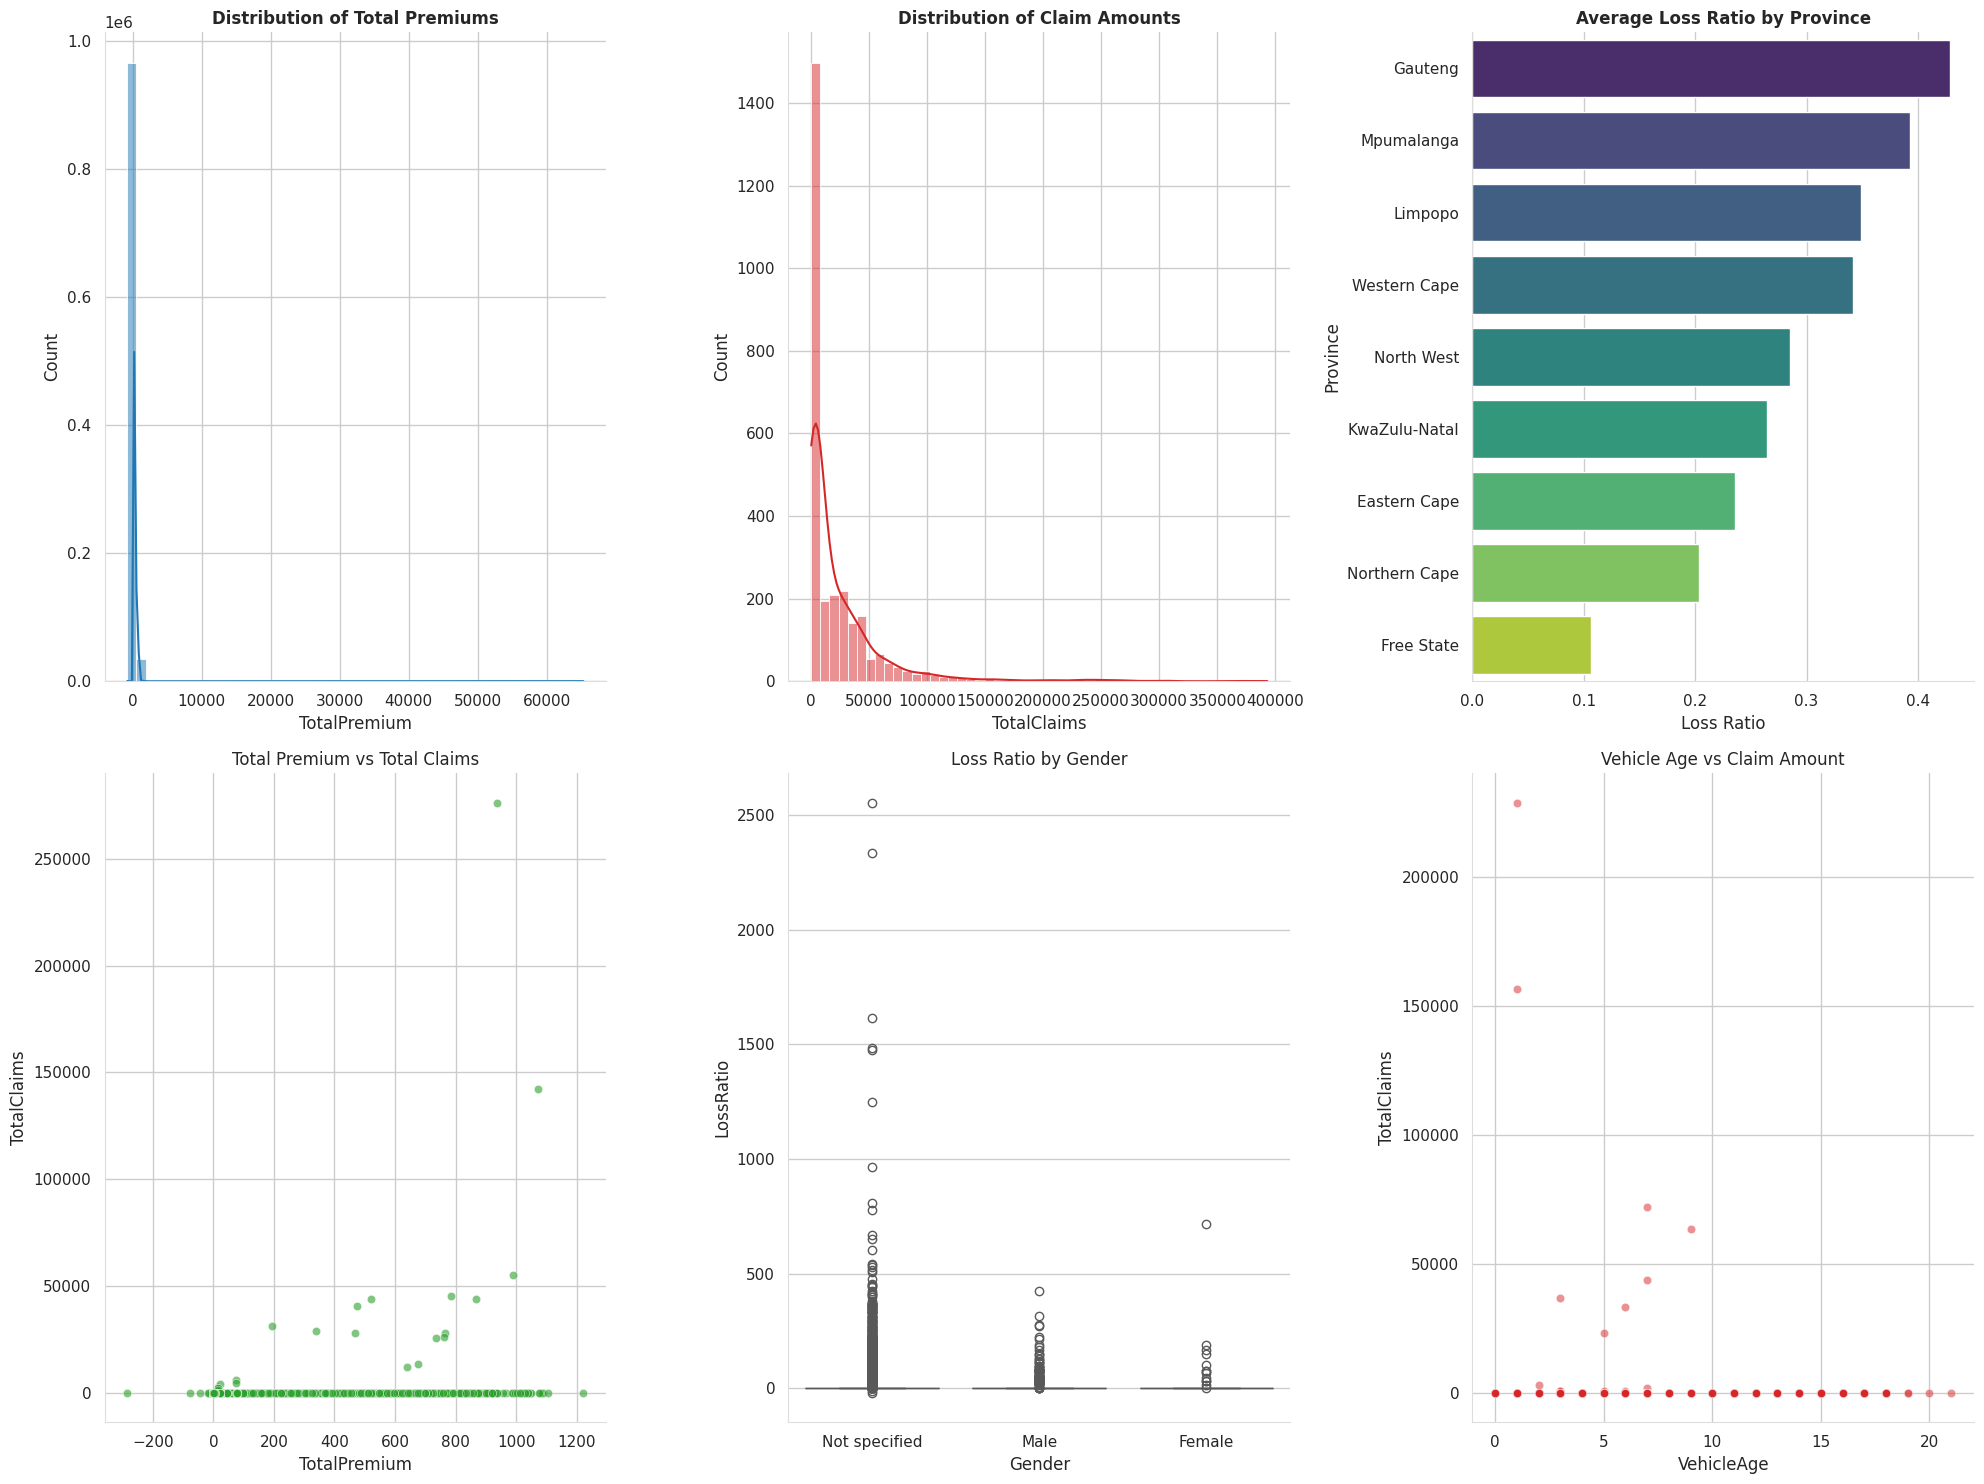

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== LOAD DATA & CREATE DERIVED COLUMNS ======================
df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep='|', low_memory=False)
df.columns = df.columns.str.strip()

# === CREATE THE MISSING COLUMNS ===
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['VehicleAge'] = 2015 - df['RegistrationYear'].fillna(2015)

print("✅ Derived columns created successfully!")
print(df[['LossRatio', 'Margin', 'VehicleAge']].head())

# ====================== NOW PLOT ======================
PALETTE = {'primary': '#1f77b4', 'accent': '#d62728', 'secondary': '#2ca02c'}

fig = plt.figure(figsize=(20, 15))

# 1. Total Premium Distribution
plt.subplot(2, 3, 1)
sns.histplot(df['TotalPremium'], kde=True, bins=50, color=PALETTE['primary'])
plt.title('Distribution of Total Premiums', fontweight='bold')

# 2. Claim Amount Distribution
plt.subplot(2, 3, 2)
claims_data = df[df['TotalClaims'] > 0]['TotalClaims']
sns.histplot(claims_data, kde=True, bins=50, color=PALETTE['accent'])
plt.title('Distribution of Claim Amounts', fontweight='bold')

# 3. Loss Ratio by Province
plt.subplot(2, 3, 3)
province_lr = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
sns.barplot(x=province_lr.values, y=province_lr.index, palette='viridis')
plt.title('Average Loss Ratio by Province', fontweight='bold')
plt.xlabel('Loss Ratio')

# 4. Premium vs Claims
plt.subplot(2, 3, 4)
sample = df.sample(min(10000, len(df)), random_state=42)
sns.scatterplot(data=sample, x='TotalPremium', y='TotalClaims', alpha=0.6, color=PALETTE['secondary'])
plt.title('Total Premium vs Total Claims')

# 5. Loss Ratio by Gender
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='Gender', y='LossRatio', palette='Set2')
plt.title('Loss Ratio by Gender')

# 6. Vehicle Age vs Claims
plt.subplot(2, 3, 6)
sns.scatterplot(data=df.sample(min(8000, len(df))), x='VehicleAge', y='TotalClaims', 
                alpha=0.5, color=PALETTE['accent'])
plt.title('Vehicle Age vs Claim Amount')

plt.tight_layout()
plt.show()

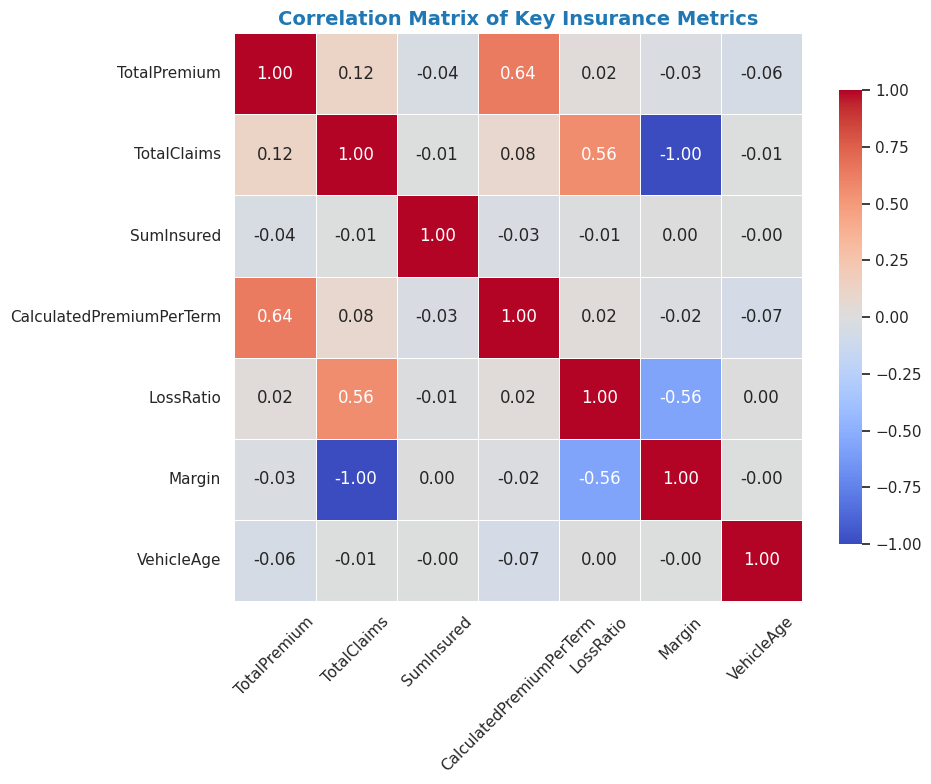

=== STRONGEST CORRELATIONS ===
TotalPremium              CalculatedPremiumPerTerm    0.635987
CalculatedPremiumPerTerm  TotalPremium                0.635987
LossRatio                 TotalClaims                 0.561102
TotalClaims               LossRatio                   0.561102
Margin                    LossRatio                  -0.562757
LossRatio                 Margin                     -0.562757
TotalClaims               Margin                     -0.995327
Margin                    TotalClaims                -0.995327
dtype: float64


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define palette (if not already defined)
PALETTE = {
    'primary': '#1f77b4',
    'accent': '#d62728'
}

# ====================== CORRELATION MATRIX - REAL COLUMNS ======================

numerical_cols = ['TotalPremium', 'TotalClaims', 'SumInsured', 
                  'CalculatedPremiumPerTerm', 'LossRatio', 
                  'Margin', 'VehicleAge']

# Create correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f", 
            linewidths=0.5,
            vmin=-1, 
            vmax=1,
            square=True,
            cbar_kws={'shrink': .8})

plt.title('Correlation Matrix of Key Insurance Metrics', 
          fontsize=14, 
          fontweight='bold', 
          color=PALETTE['primary'])
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Show strongest correlations
print("=== STRONGEST CORRELATIONS ===")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
strong_pairs = corr_pairs[(corr_pairs > 0.3) | (corr_pairs < -0.3)]
print(strong_pairs[strong_pairs != 1.0])   # Remove self-correlation

=== VEHICLE AGE RISK DIAGNOSTICS ===


,Average_Premium,Average_Claim_Amount,Claim_Frequency,Average_LossRatio,Total_Policies
VehicleAgeGroup,,,,,
New (0-5),68.91,72.62,0.29,0.36,588181
Recent (6-10),50.30,55.29,0.28,0.37,336702
Old (11-15),34.06,31.34,0.20,0.25,41884
Very Old (15+),29.70,8.89,0.10,0.08,5742


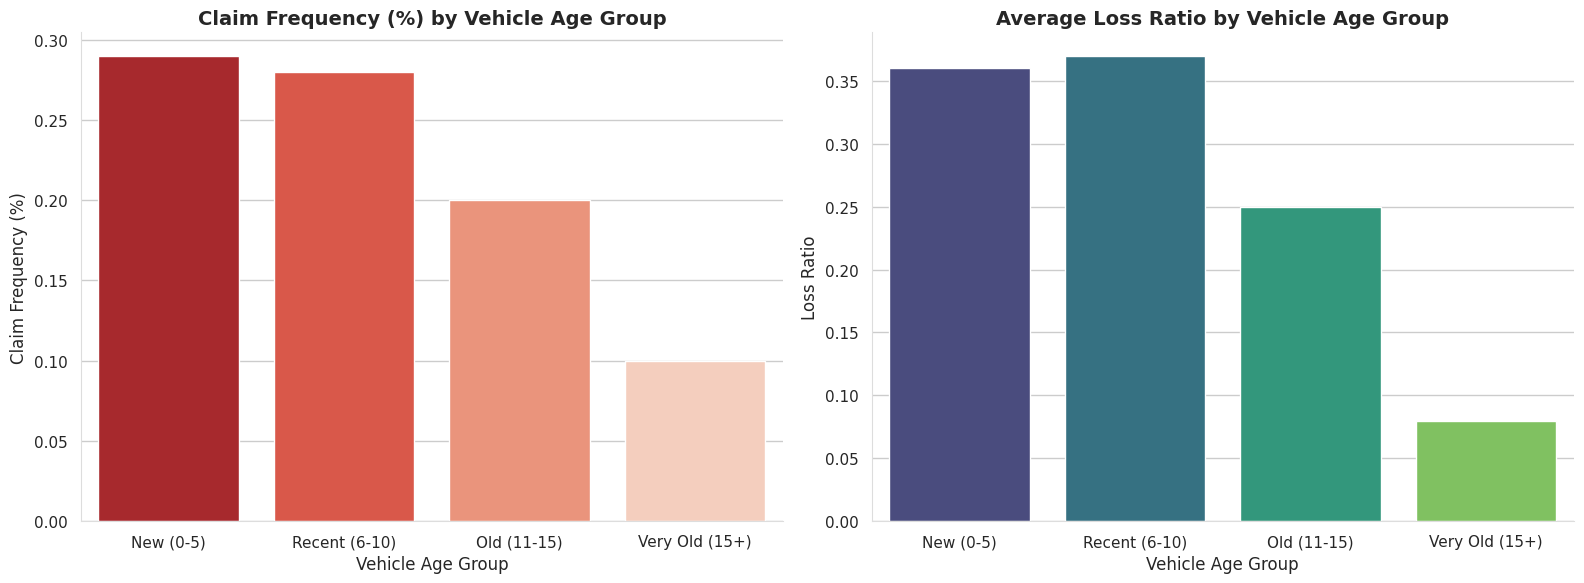

In [33]:
# ====================== 2. RISK DIAGNOSTICS BY VEHICLE AGE ======================

# Create Age Groups based on Vehicle Age (since we don't have driver Age)
df['VehicleAgeGroup'] = pd.cut(df['VehicleAge'], 
                               bins=[0, 5, 10, 15, 100], 
                               labels=['New (0-5)', 'Recent (6-10)', 'Old (11-15)', 'Very Old (15+)'])

# Grouped Analysis
age_diag = df.groupby('VehicleAgeGroup').agg(
    Average_Premium=('TotalPremium', 'mean'),
    Average_Claim_Amount=('TotalClaims', 'mean'),
    Claim_Frequency=('TotalClaims', lambda x: (x > 0).mean() * 100),
    Average_LossRatio=('LossRatio', 'mean'),
    Total_Policies=('TotalPremium', 'count')
).round(2)

print("=== VEHICLE AGE RISK DIAGNOSTICS ===")
display(age_diag)

# ====================== VISUALIZATION ======================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Claim Frequency by Vehicle Age
sns.barplot(data=age_diag.reset_index(), 
            x='VehicleAgeGroup', 
            y='Claim_Frequency', 
            palette='Reds_r', ax=axes[0])
axes[0].set_title('Claim Frequency (%) by Vehicle Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Claim Frequency (%)')
axes[0].set_xlabel('Vehicle Age Group')

# Average Loss Ratio by Vehicle Age
sns.barplot(data=age_diag.reset_index(), 
            x='VehicleAgeGroup', 
            y='Average_LossRatio', 
            palette='viridis', ax=axes[1])
axes[1].set_title('Average Loss Ratio by Vehicle Age Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loss Ratio')
axes[1].set_xlabel('Vehicle Age Group')

plt.tight_layout()
plt.show()

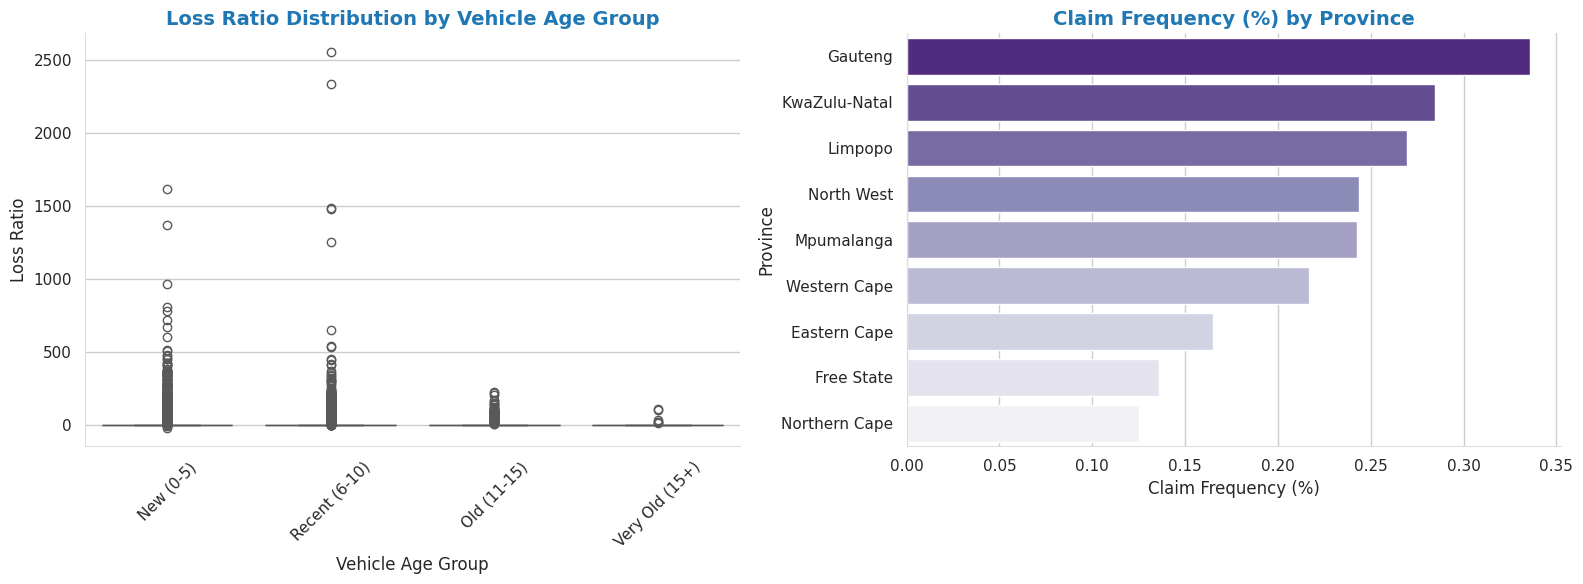

=== RISK DIAGNOSTICS SUMMARY ===


,Avg_LossRatio,Claim_Frequency,Avg_Premium,Total_Policies
VehicleAgeGroup,,,,
New (0-5),0.360,0.292,68.910,588181
Recent (6-10),0.365,0.278,50.304,336702
Old (11-15),0.249,0.201,34.057,41884
Very Old (15+),0.081,0.104,29.700,5742


In [34]:
# ====================== 3. RISK DIAGNOSTICS VISUALIZATION ======================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Loss Ratio Distribution by Vehicle Age Group
sns.boxplot(x='VehicleAgeGroup', 
            y='LossRatio', 
            data=df, 
            palette="Set2", 
            ax=axes[0])
axes[0].set_title('Loss Ratio Distribution by Vehicle Age Group', 
                  fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Vehicle Age Group')
axes[0].set_ylabel('Loss Ratio')
axes[0].tick_params(axis='x', rotation=45)

# 2. Claim Frequency by Province (as a deterrent / risk factor)
province_claim = df.groupby('Province').agg(
    Claim_Frequency=('TotalClaims', lambda x: (x > 0).mean() * 100),
    Avg_LossRatio=('LossRatio', 'mean')
).reset_index()

sns.barplot(x='Claim_Frequency', 
            y='Province', 
            data=province_claim.sort_values('Claim_Frequency', ascending=False),
            palette="Purples_r", 
            ax=axes[1])
axes[1].set_title('Claim Frequency (%) by Province', 
                  fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[1].set_xlabel('Claim Frequency (%)')
axes[1].set_ylabel('Province')

plt.tight_layout()
plt.show()

# ====================== SUMMARY TABLE ======================
print("=== RISK DIAGNOSTICS SUMMARY ===")
summary = df.groupby('VehicleAgeGroup').agg(
    Avg_LossRatio=('LossRatio', 'mean'),
    Claim_Frequency=('TotalClaims', lambda x: (x > 0).mean() * 100),
    Avg_Premium=('TotalPremium', 'mean'),
    Total_Policies=('TotalPremium', 'count')
).round(3)

display(summary)

In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ====================== 1. FEATURE ENGINEERING & DATA PREPARATION ======================

model_df = df.copy()

# Create derived features
model_df['VehicleAge'] = 2015 - model_df['RegistrationYear'].fillna(2015)
model_df['HasClaim'] = (model_df['TotalClaims'] > 0).astype(int)
model_df['LossRatio'] = model_df['TotalClaims'] / model_df['TotalPremium'].replace(0, np.nan)

# Encode categorical variables
categorical_cols = ['Gender', 'Province', 'VehicleType', 'make']
encoders = {}

for col in categorical_cols:
    if col in model_df.columns:
        le = LabelEncoder()
        model_df[col] = le.fit_transform(model_df[col].astype(str))
        encoders[col] = le

# ====================== SELECT RELEVANT FEATURES ======================
features = ['VehicleAge', 'SumInsured', 'CalculatedPremiumPerTerm', 
            'Gender', 'Province', 'VehicleType', 'make']

X = model_df[features]
y_clf = model_df['HasClaim']                    # Target: Claim Probability (Binary)

# Train-Test Split
X_train, X_test, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_clf
)

print("✅ Feature Engineering Completed!")
print(f"Training dataset dimensions : {X_train.shape}")
print(f"Testing dataset dimensions  : {X_test.shape}")
print(f"Claim Rate in Training Set  : {y_train_clf.mean():.2%}")

✅ Feature Engineering Completed!
Training dataset dimensions : (800078, 7)
Testing dataset dimensions  : (200020, 7)
Claim Rate in Training Set  : 0.28%


=== RANDOM FOREST CLASSIFIER RESULTS ===
ROC-AUC Score: 0.8863

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85    199462
           1       0.01      0.96      0.02       558

    accuracy                           0.74    200020
   macro avg       0.50      0.85      0.43    200020
weighted avg       1.00      0.74      0.85    200020



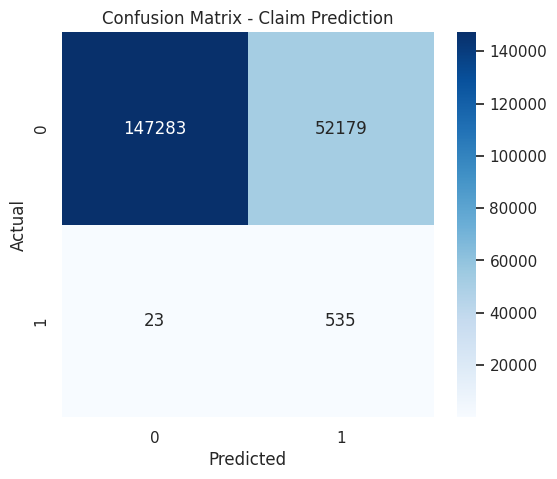

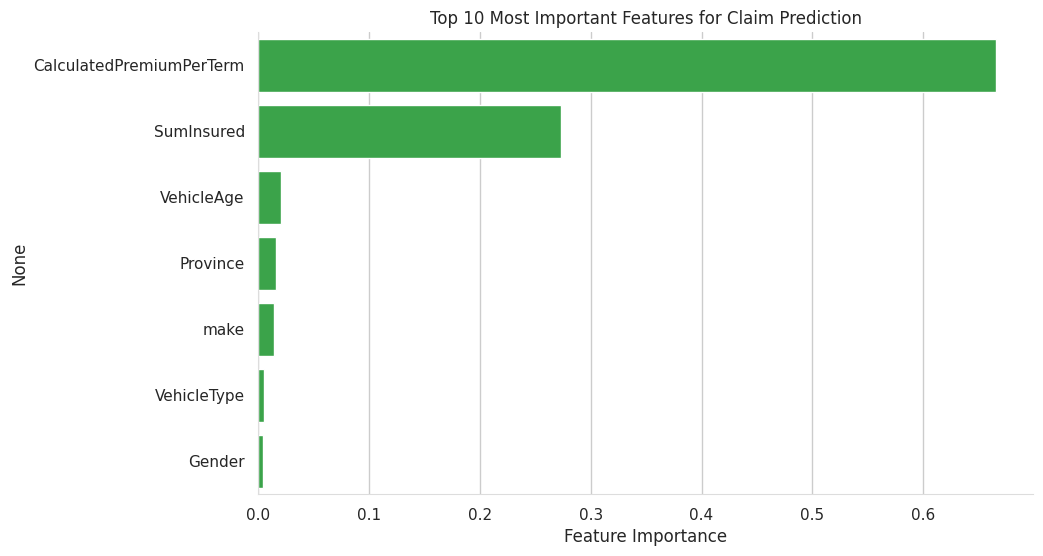


Top 10 Important Features:
CalculatedPremiumPerTerm    0.665693
SumInsured                  0.273171
VehicleAge                  0.020774
Province                    0.016302
make                        0.014111
VehicleType                 0.005327
Gender                      0.004622
dtype: float64


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== 2. TRAIN RANDOM FOREST CLASSIFIER ======================

clf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=8, 
    random_state=42,
    class_weight='balanced'   # Important because claims are rare
)

clf_model.fit(X_train, y_train_clf)

# Predictions
y_pred = clf_model.predict(X_test)
y_pred_prob = clf_model.predict_proba(X_test)[:, 1]

# Evaluation
roc_auc = roc_auc_score(y_test_clf, y_pred_prob)

print("=== RANDOM FOREST CLASSIFIER RESULTS ===")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_clf, y_pred), 
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Claim Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
importances = pd.Series(clf_model.feature_importances_, index=X_train.columns)
importances = importances.nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 10 Most Important Features for Claim Prediction')
plt.xlabel('Feature Importance')
plt.show()

print("\nTop 10 Important Features:")
print(importances)

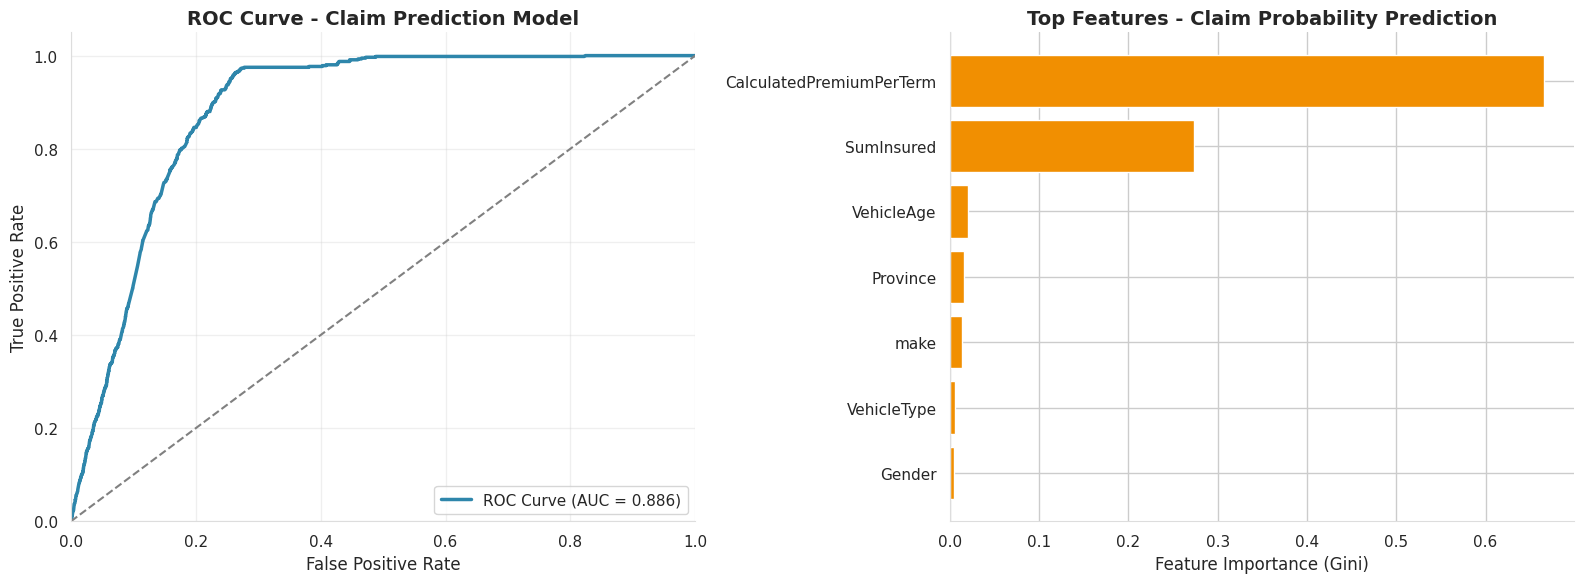

=== TOP 10 MOST IMPORTANT FEATURES ===
                    Feature  Importance
2  CalculatedPremiumPerTerm    0.665693
1                SumInsured    0.273171
0                VehicleAge    0.020774
4                  Province    0.016302
6                      make    0.014111
5               VehicleType    0.005327
3                    Gender    0.004622


In [43]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ====================== 3. ROC CURVE & FEATURE IMPORTANCE ======================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_prob)
roc_auc = roc_auc_score(y_test_clf, y_pred_prob)
PALETTE = {
    "accent": "#2E86AB",
    "secondary": "#F18F01"
}

axes[0].plot(fpr, tpr, color=PALETTE['accent'], lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve - Claim Prediction Model', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# 2. Feature Importance
importances = clf_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)

axes[1].barh(feat_imp['Feature'], feat_imp['Importance'], color=PALETTE['secondary'])
axes[1].set_xlabel('Feature Importance (Gini)', fontsize=12)
axes[1].set_title('Top Features - Claim Probability Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print Top 10 Features
print("=== TOP 10 MOST IMPORTANT FEATURES ===")
print(feat_imp.sort_values('Importance', ascending=False).head(10))

In [46]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# Only keep rows where a claim exists (NOT boolean check)
claimed_subset = model_df[model_df["TotalClaims"] > 0]

# =========================
# 2. SAFETY CHECK (VERY IMPORTANT)
# =========================
if claimed_subset.shape[0] == 0:
    raise ValueError(
        "No rows found where TotalClaims > 0. "
        "Check your data cleaning or column values."
    )

# =========================
# 3. DEFINE FEATURES & TARGET
# =========================
X_reg = claimed_subset[features]
y_reg = claimed_subset["TotalClaims"]

# =========================
# 4. TRAIN / TEST SPLIT
# =========================
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# =========================
# 5. MODEL TRAINING
# =========================
reg_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

reg_model.fit(X_train_r, y_train_r)

# =========================
# 6. PREDICTION + EVALUATION
# =========================
y_pred_r = reg_model.predict(X_test_r)

r2 = r2_score(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f"Random Forest Regressor R-squared: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

Random Forest Regressor R-squared: 0.2709
Root Mean Squared Error (RMSE): 34,242.76


In [51]:
import numpy as np

# =========================
# 1. PREDICTIONS (ALREADY DONE)
# =========================
X_all = model_df[features].copy()

model_df['PredictedClaimProb'] = clf_model.predict_proba(X_all)[:, 1]
model_df['PredictedClaimSeverity'] = reg_model.predict(X_all)

# =========================
# 2. EXPECTED LOSS (CORE INSURANCE METRIC)
# =========================
model_df['ExpectedLoss'] = (
    model_df['PredictedClaimProb'] * model_df['PredictedClaimSeverity']
)

# =========================
# 3. BASE PREMIUM (USE EXISTING COLUMN)
# =========================
base_premium = model_df['TotalPremium']

# =========================
# 4. OPTIMIZED PREMIUM MODEL
# =========================
model_df['OptimizedPremium'] = base_premium * (
    1 + model_df['ExpectedLoss']
)

# =========================
# 5. SAFETY CLIPPING (BUSINESS RULES)
# =========================
model_df['OptimizedPremium'] = np.clip(
    model_df['OptimizedPremium'],
    400,
    7500
).astype(int)

# =========================
# 6. PRESCRIPTIVE RULE ENGINE
# =========================
def prescriptive_action(row):
    if row['PredictedClaimProb'] < 0.12:
        return "Target Low-Risk Customers (Discount Strategy)"
    elif row['PredictedClaimProb'] > 0.40:
        return "High Risk - Underwriting Review Required"
    elif row['HasClaim'] == 1 and row['ExpectedLoss'] > model_df['ExpectedLoss'].quantile(0.75):
        return "Offer Risk Mitigation (Telematics / Device)"
    else:
        return "Standard Pricing & Renewal"

model_df['PrescriptiveRecommendation'] = model_df.apply(prescriptive_action, axis=1)

# =========================
# 7. SUMMARY OUTPUT
# =========================
rec_summary = model_df['PrescriptiveRecommendation'].value_counts().reset_index()
rec_summary.columns = ['Prescriptive Action', 'Policyholder Count']
rec_summary['Percentage (%)'] = (
    rec_summary['Policyholder Count'] / len(model_df)
) * 100

print("=== Prescriptive Action Recommendations ===")
print(rec_summary)

=== Prescriptive Action Recommendations ===
                             Prescriptive Action  Policyholder Count  \
0  Target Low-Risk Customers (Discount Strategy)              552293   
1       High Risk - Underwriting Review Required              272464   
2                     Standard Pricing & Renewal              175296   
3    Offer Risk Mitigation (Telematics / Device)                  45   

   Percentage (%)  
0       55.223888  
1       27.243730  
2       17.527882  
3        0.004500  


In [50]:
print(model_df.columns.tolist())

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims', 'LossRatio', 'Margin', 'VehicleAge', 'VehicleAgeGroup', 'HasClaim', 'PredictedClaimProb', 'PredictedClaimSeverity', 'ExpectedLoss', 'OptimizedPremium']


Original shape: (1000098, 59)
Clean shape: (2641, 2)
TotalPremium min/max: 1.017807017543 65282.6034210526
OptimizedPremium min/max: 232.1652418333167 638130.8913238611


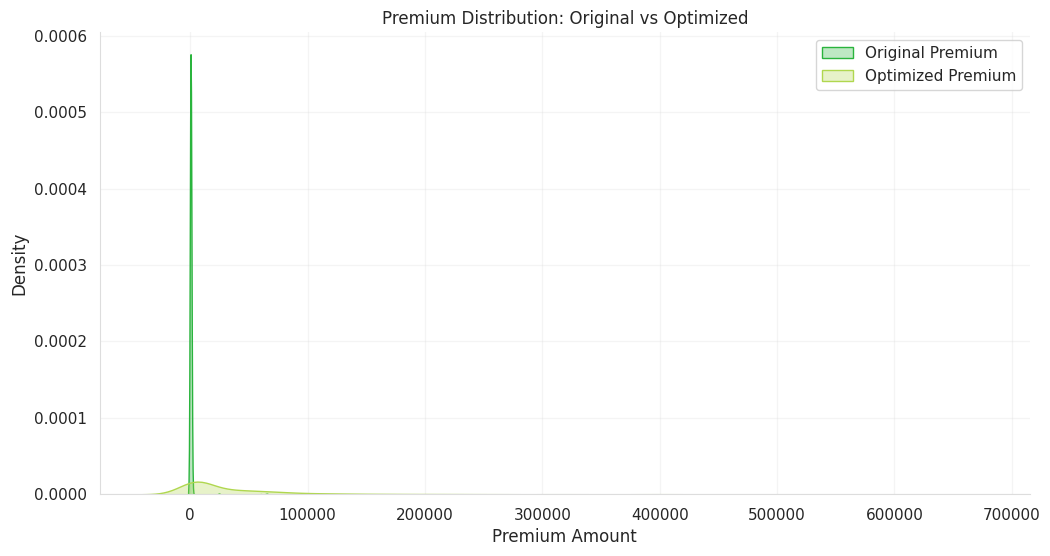

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. CLEAN DATA FIRST
# =========================
df['TotalPremium'] = pd.to_numeric(df['TotalPremium'], errors='coerce')
df['OptimizedPremium'] = pd.to_numeric(df['OptimizedPremium'], errors='coerce')

df_clean = df[['TotalPremium', 'OptimizedPremium']].dropna()

# Remove invalid or zero values
df_clean = df_clean[(df_clean['TotalPremium'] > 0) &
                    (df_clean['OptimizedPremium'] > 0)]

# =========================
# 2. CHECK DATA (IMPORTANT DEBUG)
# =========================
print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)
print("TotalPremium min/max:", df_clean['TotalPremium'].min(), df_clean['TotalPremium'].max())
print("OptimizedPremium min/max:", df_clean['OptimizedPremium'].min(), df_clean['OptimizedPremium'].max())

# =========================
# 3. PLOT
# =========================
plt.figure(figsize=(12, 6))

sns.kdeplot(
    df_clean['TotalPremium'],
    label='Original Premium',
    fill=True,
    alpha=0.3
)

sns.kdeplot(
    df_clean['OptimizedPremium'],
    label='Optimized Premium',
    fill=True,
    alpha=0.3
)

plt.title('Premium Distribution: Original vs Optimized')
plt.xlabel('Premium Amount')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

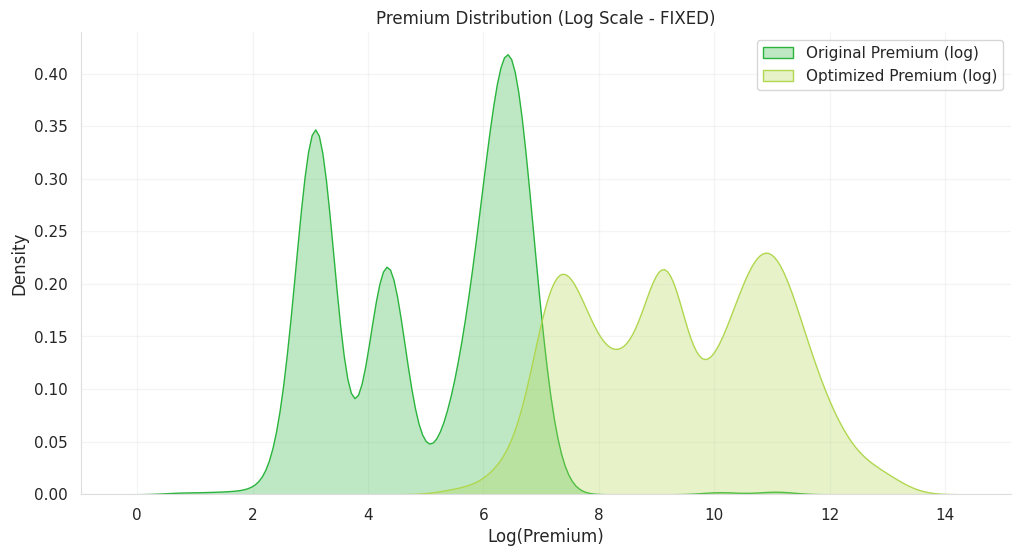

In [56]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df[(df['TotalPremium'] > 0) & (df['OptimizedPremium'] > 0)].copy()

df_plot['TotalPremium_log'] = np.log1p(df_plot['TotalPremium'])
df_plot['OptimizedPremium_log'] = np.log1p(df_plot['OptimizedPremium'])

plt.figure(figsize=(12,6))

sns.kdeplot(df_plot['TotalPremium_log'], label="Original Premium (log)", fill=True, alpha=0.3)
sns.kdeplot(df_plot['OptimizedPremium_log'], label="Optimized Premium (log)", fill=True, alpha=0.3)

plt.title("Premium Distribution (Log Scale - FIXED)")
plt.xlabel("Log(Premium)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()